In [1]:
# ============================================
# CELL: Imports
# Purpose:
# Import required libraries for generalization experiments
# ============================================

import pandas as pd

import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report

)

In [2]:
# ============================================
# CELL: Load Dataset
# Purpose:
# Load extracted PE features dataset
# ============================================

df = pd.read_csv("../data/pe_features(New_v2).csv")

print(df.shape)

df.head()

(1649, 21)


,sha256,file_name,family,file_size,num_sections,many_sections,size_of_image,size_of_code,entry_point,num_imports,...,avg_entropy,max_entropy,min_entropy,has_crypto,has_bcrypt,has_file_ops,has_version_info,has_debug,wx_sections,label
0,fac81bcdcb6ccf8505dfa44a9b4756a50e67b89f8c8fcf...,3uTools.exe,benign,13675880,6,0,13672448,9740288,8547568,4313,...,5.135459,6.374358,2.818603,0,0,1,1,1,0,0
1,8fdeb6c13162c9398e97b66c4f0a780c1e270e300a637e...,3uViewer.exe,benign,989928,6,0,978944,54784,51084,693,...,4.562831,6.085465,3.433966,0,0,0,1,1,0,0
2,7faad7057f2f88a431803c32fb7d272199bba89de3dc60...,7z.exe,benign,492608,6,0,491520,318976,319776,127,...,4.300758,6.285946,1.232928,0,0,1,1,0,0,0
3,0a038cc8dc46b6d50245c6951dc238fba63654a0cb3d23...,CrashReport.exe,benign,971992,5,0,970752,561664,383673,279,...,5.502765,6.607745,4.518242,0,0,0,0,0,0,0
4,b58aeb18d26cfd9b63c9ccfa0ebfe40d9ab7a01b4c9856...,InfInstallerx64.exe,benign,217152,6,0,221184,135680,56616,107,...,4.909627,6.413611,3.484201,0,0,0,0,1,0,0


In [3]:
# ============================================
# CELL: Dataset Inspection
# Purpose:
# Inspect family distribution
# ============================================

print(df["family"].value_counts())

family
benign         936
raworld         80
trigona         80
wannacry        80
lockbit         80
akira           80
blackmatter     80
medusa          75
qilin           59
cactus          50
blackcat        49
Name: count, dtype: int64


In [4]:
# ============================================
# CELL: Prepare Features
# Purpose:
# Separate features and labels
# ============================================

DROP_COLUMNS = [

    "label",
    "family",
    "sha256",
    "file_name"

]

X = df.drop(columns=DROP_COLUMNS)

y = df["label"]

In [30]:
# ============================================
# CELL: Define Held-Out Family
# Purpose:
# Select unseen ransomware family for testing
# ============================================

UNSEEN_FAMILY = "medusa"

In [32]:
# ============================================
# CELL: Family-Aware Split
# Purpose:
# Train on all families except the held-out family
# ============================================

train_mask = df["family"] != UNSEEN_FAMILY

test_mask = df["family"] == UNSEEN_FAMILY

X_train = X[train_mask]

y_train = y[train_mask]

X_test = X[test_mask]

y_test = y[test_mask]

print("[INFO] Train samples:", len(X_train))

print("[INFO] Test ransomware samples:", len(X_test))

[INFO] Train samples: 1574
[INFO] Test ransomware samples: 75


In [33]:
# ============================================
# CELL: Add Benign Samples
# Purpose:
# Add benign files to held-out family test set
# ============================================

benign_mask = df["family"] == "benign"

X_benign = X[benign_mask].sample(

    100,

    random_state=42

)

y_benign = y[benign_mask].sample(

    100,

    random_state=42

)

X_test = pd.concat([

    X_test,
    X_benign

])

y_test = pd.concat([

    y_test,
    y_benign

])

print("[INFO] Final test samples:", len(X_test))

[INFO] Final test samples: 175


In [34]:
# ============================================
# CELL: Train Model
# Purpose:
# Train RandomForest on known ransomware families
# ============================================

model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

model.fit(

    X_train,

    y_train

)

print("[SUCCESS] Model trained")

[SUCCESS] Model trained


In [35]:
# ============================================
# CELL: Evaluate Model
# Purpose:
# Evaluate performance on unseen ransomware family
# ============================================

pred = model.predict(X_test)

print(classification_report(

    y_test,

    pred

))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83       100
           1       1.00      0.47      0.64        75

    accuracy                           0.77       175
   macro avg       0.86      0.73      0.73       175
weighted avg       0.84      0.77      0.75       175



In [36]:
# ============================================
# CELL: Metrics
# Purpose:
# Compute evaluation metrics
# ============================================

acc = accuracy_score(y_test, pred)

precision = precision_score(y_test, pred)

recall = recall_score(y_test, pred)

f1 = f1_score(y_test, pred)

print(f"Accuracy : {acc:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7714
Precision: 1.0000
Recall   : 0.4667
F1 Score : 0.6364


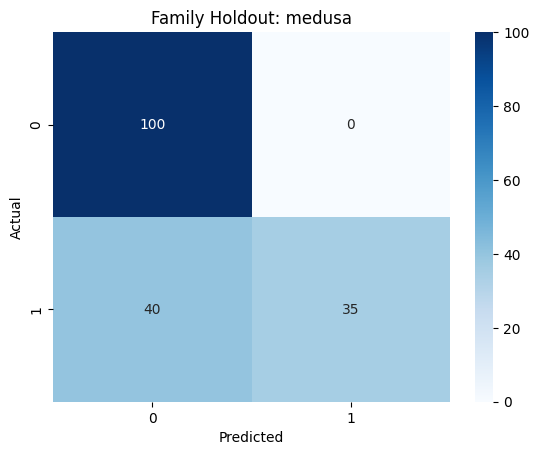

In [37]:
# ============================================
# CELL: Confusion Matrix
# Purpose:
# Visualize prediction performance
# ============================================

from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(

    y_test,

    pred

)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(

    f"Family Holdout: {UNSEEN_FAMILY}"

)

plt.show()

In [38]:
# ============================================
# CELL: False Negative Analysis
# Purpose:
# Analyze ransomware samples missed by the model
# ============================================

fn_mask = (

    (y_test == 1)

    &

    (pred == 0)

)

fn_samples = X_test[fn_mask]

print("=" * 60)

print("False Negative Samples")

print("=" * 60)

print(

    f"[INFO] False Negatives: {len(fn_samples)}"

)

print("\nFalse Negative Mean Features:\n")

print(

    fn_samples.mean()

)

# ============================================
# Compare with True Positives
# ============================================

tp_mask = (

    (y_test == 1)

    &

    (pred == 1)

)

tp_samples = X_test[tp_mask]

print("\n" + "=" * 60)

print("True Positive Samples")

print("=" * 60)

print(

    f"[INFO] True Positives: {len(tp_samples)}"

)

print("\nTrue Positive Mean Features:\n")

print(

    tp_samples.mean()

)

False Negative Samples
[INFO] False Negatives: 40

False Negative Mean Features:

file_size           687809.000000
num_sections             5.200000
many_sections            0.125000
size_of_image       705331.200000
size_of_code        470156.800000
entry_point         237492.325000
num_imports            186.700000
num_dlls                10.650000
avg_entropy              5.221207
max_entropy              6.568816
min_entropy              3.520308
has_crypto               1.000000
has_bcrypt               0.000000
has_file_ops             0.925000
has_version_info         0.000000
has_debug                1.000000
wx_sections              0.000000
dtype: float64

True Positive Samples
[INFO] True Positives: 35

True Positive Mean Features:

file_size           591520.971429
num_sections             4.971429
many_sections            0.000000
size_of_image       673402.057143
size_of_code        447751.314286
entry_point         266900.400000
num_imports            140.571429
num_dll

In [39]:
medusa_samples = df[df["family"] == "medusa"]
other_ransomware = df[(df["label"] == 1) & (df["family"] != "medusa")]

print("Medusa avg features:")
print(medusa_samples[X.columns].mean())

print("\nOther ransomware avg features:")
print(other_ransomware[X.columns].mean())

Medusa avg features:
file_size           642874.586667
num_sections             5.093333
many_sections            0.066667
size_of_image       690430.933333
size_of_code        459700.906667
entry_point         251216.093333
num_imports            165.173333
num_dlls                 8.293333
avg_entropy              5.361656
max_entropy              6.758437
min_entropy              3.675508
has_crypto               0.946667
has_bcrypt               0.320000
has_file_ops             0.560000
has_version_info         0.013333
has_debug                0.960000
wx_sections              0.093333
dtype: float64

Other ransomware avg features:
file_size           2.633786e+06
num_sections        7.686520e+00
many_sections       6.065831e-01
size_of_image       2.740360e+06
size_of_code        8.016227e+05
entry_point         4.663341e+05
num_imports         1.076520e+02
num_dlls            6.180251e+00
avg_entropy         4.144270e+00
max_entropy         6.851084e+00
min_entropy         1.35

In [40]:
# ============================= Test on other unseen rasnomware families =========================================

In [41]:
print(df["family"].unique())

<StringArray>
[     'benign',     'raworld',     'trigona',      'medusa',    'wannacry',
      'cactus',     'lockbit',       'akira',       'qilin', 'blackmatter',
    'blackcat']
Length: 11, dtype: str


[INFO] Dataset Shape: (1991, 21)

[INFO] Testing unseen family: hellokitty
[INFO] Train Samples: 1765
[INFO] Test Ransomware Samples: 48
[INFO] Final Test Samples: 148
[SUCCESS] Model trained

Accuracy : 0.7973
Precision: 1.0000
Recall   : 0.3750
F1 Score : 0.5455


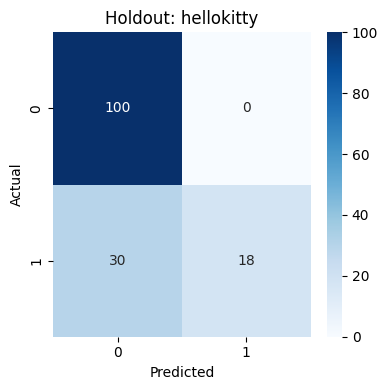


[INFO] Testing unseen family: bianlian
[INFO] Train Samples: 1765
[INFO] Test Ransomware Samples: 37
[INFO] Final Test Samples: 137
[SUCCESS] Model trained

Accuracy : 0.7518
Precision: 1.0000
Recall   : 0.0811
F1 Score : 0.1500


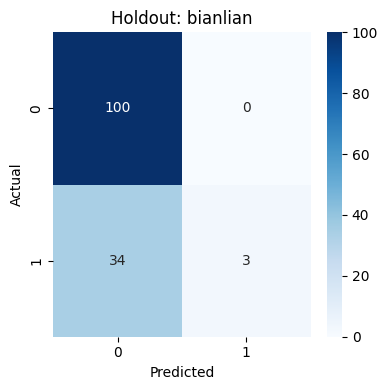


[INFO] Testing unseen family: rhysida
[INFO] Train Samples: 1765
[INFO] Test Ransomware Samples: 27
[INFO] Final Test Samples: 127
[SUCCESS] Model trained

Accuracy : 0.9843
Precision: 1.0000
Recall   : 0.9259
F1 Score : 0.9615


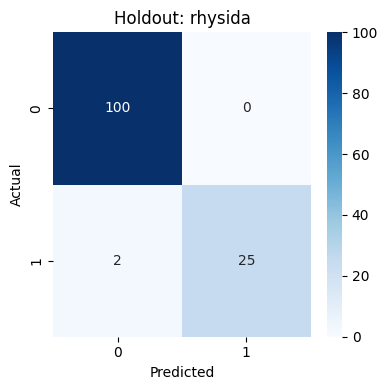


[INFO] Testing unseen family: dragonforce
[INFO] Train Samples: 1765
[INFO] Test Ransomware Samples: 20
[INFO] Final Test Samples: 120
[SUCCESS] Model trained

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


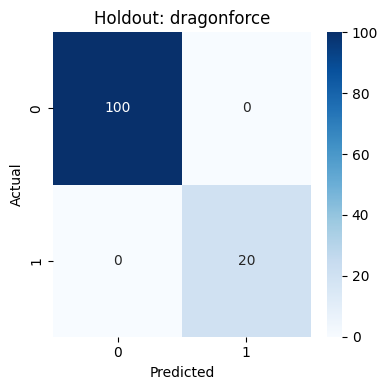


[INFO] Testing unseen family: fog
[INFO] Train Samples: 1765
[INFO] Test Ransomware Samples: 17
[INFO] Final Test Samples: 117
[SUCCESS] Model trained

Accuracy : 0.9744
Precision: 1.0000
Recall   : 0.8235
F1 Score : 0.9032


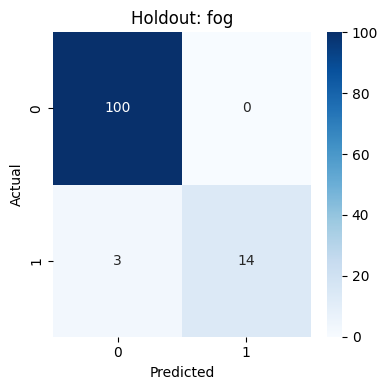


FINAL RESULTS
             samples  accuracy  precision  recall      f1
bianlian       137.0    0.7518        1.0  0.0811  0.1500
hellokitty     148.0    0.7973        1.0  0.3750  0.5455
fog            117.0    0.9744        1.0  0.8235  0.9032
rhysida        127.0    0.9843        1.0  0.9259  0.9615
dragonforce    120.0    1.0000        1.0  1.0000  1.0000


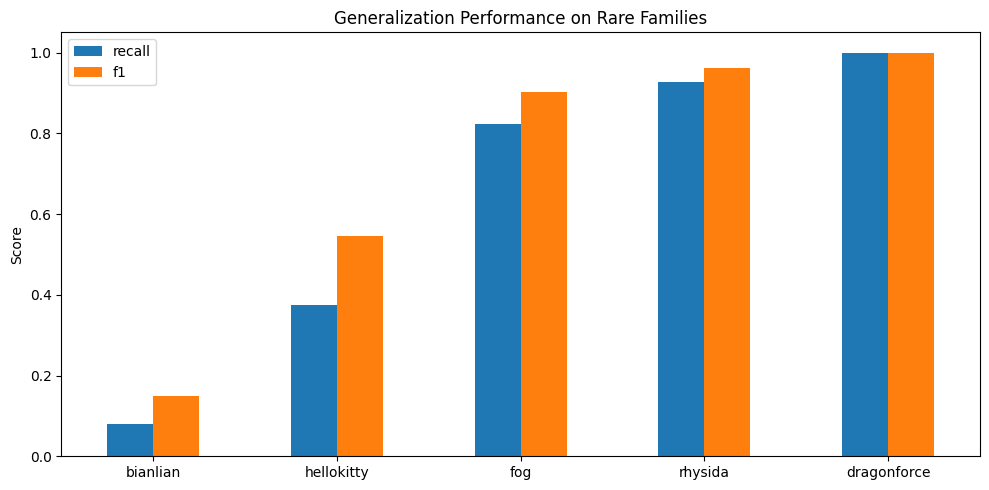

In [42]:
# ============================================
# CELL: Rare Family Generalization Experiment
# Purpose:
# Train on large ransomware families
# Test on unseen rare ransomware families
# ============================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("../data/pe_features(Combined_v2).csv")

print("[INFO] Dataset Shape:", df.shape)

# ============================================
# Prepare Features
# ============================================

DROP_COLUMNS = [

    "label",
    "family",
    "sha256",
    "file_name"

]

X = df.drop(columns=DROP_COLUMNS)

y = df["label"]

# ============================================
# Large Families Used For Training
# ============================================

TRAIN_FAMILIES = [

    "blackmatter",
    "wannacry",
    "raworld",
    "akira",
    "trigona",
    "lockbit",
    "medusa",
    "qilin",
    "cactus"

]

# ============================================
# Rare Families Used For Testing
# ============================================

HELD_OUT_FAMILIES = [

    "hellokitty",
    "bianlian",
    "rhysida",
    "dragonforce",
    "fog"

]

# ============================================
# Store Results
# ============================================

all_results = {}

# ============================================
# Main Experiment Loop
# ============================================

for UNSEEN_FAMILY in HELD_OUT_FAMILIES:

    print("\n" + "=" * 60)

    print(f"[INFO] Testing unseen family: {UNSEEN_FAMILY}")

    # ========================================
    # Create Train/Test Split
    # ========================================

    train_mask = (
    df["family"].isin(TRAIN_FAMILIES) |
    (df["family"] == "benign")         
)

    test_mask = df["family"] == UNSEEN_FAMILY

    X_train = X[train_mask]

    y_train = y[train_mask]

    X_test = X[test_mask]

    y_test = y[test_mask]

    print(f"[INFO] Train Samples: {len(X_train)}")

    print(f"[INFO] Test Ransomware Samples: {len(X_test)}")

    # ========================================
    # Add Benign Samples To Test Set
    # ========================================

    benign_mask = df["family"] == "benign"

    X_benign = X[benign_mask].sample(

        100,

        random_state=42

    )

    y_benign = y[benign_mask].sample(

        100,

        random_state=42

    )

    X_test = pd.concat([

        X_test,
        X_benign

    ])

    y_test = pd.concat([

        y_test,
        y_benign

    ])

    print(f"[INFO] Final Test Samples: {len(X_test)}")

    # ========================================
    # Train Model
    # ========================================

    model = RandomForestClassifier(

        n_estimators=200,

        random_state=42

    )

    model.fit(

        X_train,

        y_train

    )

    print("[SUCCESS] Model trained")

    # ========================================
    # Predict
    # ========================================

    pred = model.predict(X_test)

    # ========================================
    # Metrics
    # ========================================

    acc = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    print(f"\nAccuracy : {acc:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    # ========================================
    # Save Results
    # ========================================

    all_results[UNSEEN_FAMILY] = {

        "samples": len(X_test),

        "accuracy": acc,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

    # ========================================
    # Confusion Matrix
    # ========================================

    cm = confusion_matrix(

        y_test,

        pred

    )

    plt.figure(figsize=(4,4))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues"

    )

    plt.title(

        f"Holdout: {UNSEEN_FAMILY}"

    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.tight_layout()

    plt.show()

# ============================================
# Summary Table
# ============================================

print("\n" + "=" * 60)

print("FINAL RESULTS")

print("=" * 60)

results_df = pd.DataFrame(all_results).T

results_df = results_df.sort_values(

    "recall",

    ascending=True

)

print(results_df.round(4))

# ============================================
# Visualization
# ============================================

results_df.plot(

    kind="bar",

    y=["recall", "f1"],

    figsize=(10,5)

)

plt.title(

    "Generalization Performance on Rare Families"

)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [43]:
# dragonforce: Accuracy=1.0, Precision=1.0, Recall=1.0
# Perfect score on unseen family = very suspicious.
# The perfect score on dragonforce is not due to similarity to blackmatter.
# Most likely reason: Dragonforce is similar to other training families (raworld, akira, trigona) in import count and crypto APIs. 
# The model learned this pattern from other families and applied it to them.

df_dragon = df[df["family"] == "dragonforce"]
df_black  = df[df["family"] == "blackmatter"]

print("DragonForce feature means:")
print(df_dragon[X.columns].mean())

print("\nBlackMatter feature means:")
print(df_black[X.columns].mean())

DragonForce feature means:
file_size           419913.300000
num_sections             5.050000
many_sections            0.000000
size_of_image       429670.400000
size_of_code        325068.800000
entry_point         213344.900000
num_imports            169.350000
num_dlls                10.100000
avg_entropy              5.701170
max_entropy              6.666638
min_entropy              4.524172
has_crypto               0.850000
has_bcrypt               0.000000
has_file_ops             0.950000
has_version_info         0.000000
has_debug                1.000000
wx_sections              0.000000
dtype: float64

BlackMatter feature means:
file_size           523031.055118
num_sections             5.559055
many_sections            0.062992
size_of_image       574478.110236
size_of_code         84556.598425
entry_point         377882.661417
num_imports             20.724409
num_dlls                 2.653543
avg_entropy              5.598214
max_entropy              7.682081
min_entropy 

In [44]:
# feature comparison: BianLian is structurally different from all the training families in almost every feature.
# Conclusion: BianLian evades static PE detection because it doesn't use standard Windows Crypto APIs 
# and has significantly different structural characteristics from known ransomware families.
# File size: double the average, num_dlls decreased by 72%, has_crypto = 0 (no crypto API in import table), min_entropy is very low = not packed

df_bian   = df[df["family"] == "bianlian"]
df_train  = df[df["family"].isin(TRAIN_FAMILIES)]

print("BianLian vs Training families:")
comparison = pd.DataFrame({
    "bianlian": df_bian[X.columns].mean(),
    "training_avg": df_train[X.columns].mean()
})
print(comparison.round(3))

BianLian vs Training families:
                     bianlian  training_avg
file_size         4367672.324   2093464.908
num_sections            5.919         7.162
many_sections           0.081         0.496
size_of_image     3644111.568   2167617.663
size_of_code      1336721.297    512194.523
entry_point        415081.459    443960.689
num_imports            46.108        98.369
num_dlls                1.595         5.748
avg_entropy             4.283         4.299
max_entropy             6.294         6.784
min_entropy             0.311         1.721
has_crypto              0.000         0.105
has_bcrypt              0.000         0.039
has_file_ops            0.027         0.446
has_version_info        0.027         0.025
has_debug               0.081         0.522
wx_sections             0.054         0.136


In [45]:
import pandas as pd
df = pd.read_csv("../data/pe_features(Combined).csv")
print(df["many_sections"].value_counts())
print("\nSamples where num_sections > 6:", (df["num_sections"] > 6).sum())
print("Samples where many_sections == 1:", (df["many_sections"] == 1).sum())

many_sections
0    1137
1     848
Name: count, dtype: int64

Samples where num_sections > 6: 848
Samples where many_sections == 1: 848


In [46]:
import pefile
import os
import pandas as pd
from collections import defaultdict

RANSOMWARE_FOLDER = "../dataset/ransomware"
BENIGN_FOLDER     = "../dataset/benign"

results = defaultdict(list)

for label, folder in [("benign", BENIGN_FOLDER), ("ransomware", RANSOMWARE_FOLDER)]:
    
    all_files = []
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".exe", ".dll")):
                all_files.append(os.path.join(root, f))
    
    for fpath in all_files[:80]:
        pe = None
        try:
            pe = pefile.PE(fpath, fast_load=True)
            pe.parse_data_directories(directories=[
                pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_RESOURCE'],
                pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_DEBUG'],
                pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_IMPORT'],
            ])

            # has_version_info — RT_VERSION = resource type 16
            has_version = 0
            if hasattr(pe, 'DIRECTORY_ENTRY_RESOURCE'):
                for res_type in pe.DIRECTORY_ENTRY_RESOURCE.entries:
                    if hasattr(res_type, 'id') and res_type.id == 16:
                        has_version = 1
                        break

            # has_debug — index 6
            try:
                has_debug = int(pe.OPTIONAL_HEADER.DATA_DIRECTORY[6].Size > 0)
            except Exception:
                has_debug = 0

            # wx_sections
            wx = sum(
                1 for s in pe.sections
                if (s.Characteristics & 0x20000000) and
                   (s.Characteristics & 0x80000000)
            )

            results["label"].append(label)
            results["has_version_info"].append(has_version)
            results["has_debug"].append(has_debug)
            results["wx_sections"].append(wx)

        except Exception:
            pass
        finally:
            if pe is not None:
                pe.close()

df_test = pd.DataFrame(results)
print(f"[INFO] Processed: {len(df_test)}")
print("\n[INFO] Feature averages by label:")
print(df_test.groupby("label")[["has_version_info","has_debug","wx_sections"]].mean().round(3))

[INFO] Processed: 159

[INFO] Feature averages by label:
            has_version_info  has_debug  wx_sections
label                                               
benign                 0.688      0.850        0.025
ransomware             0.038      0.582        0.063


In [ ]:
#=========================== Feature Ablation Experiment ================================

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

df = pd.read_csv("../data/pe_features(New_v2).csv")

DROP_COLUMNS = ["label", "family", "sha256", "file_name"]
X = df.drop(columns=DROP_COLUMNS)
y = df["label"]

# ================================
# Feature Groups
# ================================
FEATURE_GROUPS = {

    "entropy": [
        "avg_entropy", "max_entropy", "min_entropy"
    ],

    "imports": [
        "num_imports", "num_dlls",
        "has_crypto", "has_bcrypt", "has_file_ops"
    ],

    "structure": [
        "file_size", "num_sections", "many_sections",
        "size_of_image", "size_of_code", "entry_point"
    ],

    "new_features": [
        "has_version_info", "has_debug", "wx_sections"
    ],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ================================
# Baseline — كل الـ features
# ================================
baseline = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X, y, cv=cv, scoring="f1"
).mean()

print(f"Baseline (all features): F1 = {baseline:.4f}")
print("=" * 50)

# ================================
# Ablation
# ================================
results = {"baseline (all features)": baseline}

for group_name, features in FEATURE_GROUPS.items():

    X_ablated = X.drop(columns=features, errors="ignore")

    score = cross_val_score(
        RandomForestClassifier(n_estimators=200, random_state=42),
        X_ablated, y, cv=cv, scoring="f1"
    ).mean()

    drop = baseline - score

    results[f"without {group_name}"] = score

    print(f"Without {group_name:<15}: F1 = {score:.4f}  (drop = {drop:+.4f})")

# ================================
# Summary
# ================================
print("\n" + "=" * 50)
print("Most important group = biggest drop when removed")

Baseline (all features): F1 = 0.9780
Without entropy        : F1 = 0.9767  (drop = +0.0013)
Without imports        : F1 = 0.9731  (drop = +0.0049)
Without structure      : F1 = 0.9760  (drop = +0.0020)
Without new_features   : F1 = 0.9660  (drop = +0.0120)

Most important group = biggest drop when removed


In [ ]:
# ========================== Confidence Distribution Analysis ==================================
# To show how much the model is confident in his wrong decisions.

False Negatives:  7
  Mean confidence: 0.280
  Min confidence:  0.055
  Max confidence:  0.470

False Positives:  2
  Mean confidence: 0.750

True Positives:   136
  Mean confidence: 0.976

High-confidence FN (prob < 0.3): 3
→ The model is sure they are benign and they are ransomware


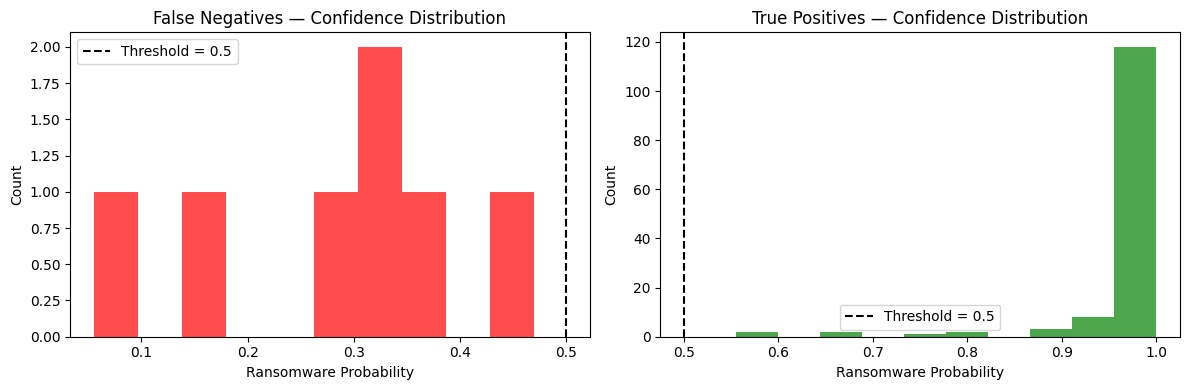

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/pe_features(New_v2).csv")

DROP_COLUMNS = ["label", "family", "sha256", "file_name"]
X = df.drop(columns=DROP_COLUMNS)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

# ================================
# False Negatives
# ================================
fn_mask = (y_test == 1) & (preds == 0)
fp_mask = (y_test == 0) & (preds == 1)
tp_mask = (y_test == 1) & (preds == 1)
tn_mask = (y_test == 0) & (preds == 0)

fn_probs = probs[fn_mask]
fp_probs = probs[fp_mask]
tp_probs = probs[tp_mask]
tn_probs = probs[fp_mask]

print("=" * 50)
print(f"False Negatives:  {fn_mask.sum()}")
print(f"  Mean confidence: {fn_probs.mean():.3f}")
print(f"  Min confidence:  {fn_probs.min():.3f}")
print(f"  Max confidence:  {fn_probs.max():.3f}")

print(f"\nFalse Positives:  {fp_mask.sum()}")
print(f"  Mean confidence: {fp_probs.mean():.3f}")

print(f"\nTrue Positives:   {tp_mask.sum()}")
print(f"  Mean confidence: {tp_probs.mean():.3f}")

# ================================
# High-confidence errors
# ================================
high_conf_fn = fn_probs[fn_probs < 0.3]
print(f"\nHigh-confidence FN (prob < 0.3): {len(high_conf_fn)}")
print("→ The model is sure they are benign and they are ransomware")

# ================================
# Plot
# ================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fn_probs, bins=10, color="red", alpha=0.7)
axes[0].set_title("False Negatives — Confidence Distribution")
axes[0].set_xlabel("Ransomware Probability")
axes[0].set_ylabel("Count")
axes[0].axvline(x=0.5, color="black", linestyle="--", label="Threshold = 0.5")
axes[0].legend()

axes[1].hist(tp_probs, bins=10, color="green", alpha=0.7)
axes[1].set_title("True Positives — Confidence Distribution")
axes[1].set_xlabel("Ransomware Probability")
axes[1].set_ylabel("Count")
axes[1].axvline(x=0.5, color="black", linestyle="--", label="Threshold = 0.5")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# Try differnet thresholds 

from sklearn.metrics import recall_score, precision_score

thresholds = [0.5, 0.4, 0.3, 0.2]

print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<10}")
print("-" * 32)

for thresh in thresholds:
    preds_thresh = (probs >= thresh).astype(int)
    r = recall_score(y_test, preds_thresh)
    p = precision_score(y_test, preds_thresh)
    print(f"{thresh:<12} {r:.4f}     {p:.4f}")

Threshold    Recall     Precision 
--------------------------------
0.5          0.9510     0.9855
0.4          0.9580     0.9856
0.3          0.9790     0.9524
0.2          0.9860     0.9338
